# Exercice 3. Remplacez la Q-table par un cerveau neuronal (DQN)
## Projet Eagle-1 · AstroDynamics · OpenClassrooms
**Auteur :** Rafael Cerezo Martin

**Date :** Juin 2026

---

### Objectif
Remplacer la Q-table (discrete, limitee) par un **reseau neuronal** capable
d'approximer Q(s,a) sur des espaces d'etats continus.

**Deux implementations :**
1. **Manuel avec PyTorch** — comprendre les rouages : DQN, Experience Replay, Target Network
2. **Stable-Baselines3** — implementation professionnelle en quelques lignes

**Environnement :** `CartPole-v1`  
**Espace d'observation :** `Box(4,)` continu — Q-table impossible  
**Espace d'action :** `Discrete(2)` — 0=gauche, 1=droite  
**Critere de succes :** recompense moyenne >= 200 sur 100 episodes

**ATTENTION: DQN n'est pas deterministe**

Sources d'aléa (Sources de stochasticité) :

1. Initialisation aléatoire du policy_net
   → poids de fc1, fc2, fc3 aléatoires au départ

2. Échantillonnage aléatoire du replay buffer
   → replay.sample(64) — 64 transitions différentes à chaque fois

3. Actions ε-greedy (epsilon-greedy)
   → random.random() < epsilon — différent à chaque fois

---
### [Cellule] Installation et chargement des modules core

In [1]:
# !pip install gymnasium stable-baselines3 -q

# ============================================================
# ENVIRONNEMENT — détection automatique Colab / local
# ============================================================
import sys                                     # gestion du chemin Python
import os                                      # opérations système
from pathlib import Path                       # chemins portables
from datetime import datetime                  # pour ajouter date dans les noms de fichiers

print(sys.version)

try:
    import google.colab                        # disponible uniquement sur Colab
    BASE = Path(
        '/content/drive/MyDrive/OpenClassrooms'
        '/M11_Entrainez_votre_agent_RL/m11_ocr'
    )
except ImportError:
    BASE = Path().resolve().parent             # notebooks/ → m11_ocr/

CORE   = BASE / 'core'                        # modules utilitaires du projet
MODELS = BASE / 'models'                      # modèles entraînés sauvegardés
MODELS.mkdir(exist_ok=True)                   # créer si absent

sys.path.insert(0, str(CORE))                 # rendre les modules importables

# ── Chemins fichiers ──────────────────────────────────────────

ts       = datetime.now().strftime("%y%m%d_%H%M%S")   # 250619_143022

LOGS_DQN_SB3_TRAIN    = BASE / 'logs' / f"ex3_{ts}_dqn_sb3_train"  
LOGS_DQN_SB3_EVAL     = BASE / 'logs' / f"ex3_{ts}_dqn_sb3_eval"  

LOGS_DQN_SB3_TRAIN.mkdir(parents=True, exist_ok=True)
LOGS_DQN_SB3_EVAL.mkdir(parents=True,  exist_ok=True)


LOGS_DQN_MAN_TRAIN = BASE / 'logs' / f"ex3_{ts}_dqn_manual_train"
LOGS_DQN_MAN_TRAIN.mkdir(parents=True, exist_ok=True)

LOGS_DQN_MAN_EVAL = BASE / 'logs' / f"ex3_{ts}_dqn_manual_eval"
LOGS_DQN_MAN_EVAL.mkdir(parents=True, exist_ok=True)

# ============================================================
# MODULES CORE DU PROJET
# ============================================================
from env_utils import make_env                 # création d'environnements Gym
from env_utils import inspect_env              # inspection des espaces
from env_utils import run_n_random_episodes    # épisodes politique aléatoire

from metrics   import compute_stats            # statistiques descriptives
from metrics   import print_stats              # affichage formaté des stats
from metrics   import moving_average           # moyenne glissante
from metrics   import success_rate             # taux de réussite

from viz_utils import plot_episode_metrics     # courbes récompense/pas
from viz_utils import plot_reward_distribution # histogramme des récompenses
from viz_utils import animate_episode_with_metrics  # animation avec métriques
from viz_utils import show_env_frame           # affichage frame statique
from viz_utils import plot_q_directional_map   # carte directionnelle Q-table

# ============================================================
# BIBLIOTHÈQUES SCIENTIFIQUES
# ============================================================
import numpy              as np               # calcul vectoriel et matriciel
import pandas             as pd               # tableaux de données
import pickle                                 # sérialisation Q-table
import random                                 # génération aléatoire Python

# ============================================================
# DEEP LEARNING — PyTorch
# ============================================================
import torch                                  # framework deep learning
import torch.nn           as nn               # couches et modules neuronaux
import torch.nn.functional as F               # fonctions d'activation
import torch.optim        as optim            # optimiseurs (Adam, SGD…)

# ============================================================
# ENVIRONNEMENTS DE SIMULATION — Gymnasium
# ============================================================
import gymnasium          as gym              # environnements RL standardisés

# ============================================================
# VISUALISATION — Matplotlib
# ============================================================
%matplotlib inline
import matplotlib                             # configuration du backend
import matplotlib.pyplot   as plt             # tracé de graphiques
import matplotlib.patches  as patches         # formes géométriques (FancyBox…)
import matplotlib.animation as animation      # animations frame par frame
import matplotlib.gridspec  as gridspec       # mise en page multi-panneaux

# ============================================================
# UTILITAIRES PYTHON
# ============================================================
from collections      import deque            # buffer circulaire
from IPython.display  import HTML, display    # affichage HTML dans le notebook

# ============================================================
# VÉRIFICATION DE L'ENVIRONNEMENT
# ============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED      = 42                                # graine reproductibilité
SEED_EVAL = 99                                # graine évaluation distincte
WINDOW    = 50                                # fenêtre moyenne glissante


print("\n============================================================")
print("VÉRIFICATION DE L'ENVIRONNEMENT")
print("============================================================")
print(f"  Gymnasium...........: {gym.__version__}")
print(f"  NumPy...............: {np.__version__}")
print(f"  GPU disponible......: False  (non requis pour Q-Learning)")
print(f"  Backend matplotlib..: {matplotlib.get_backend()}")
print("============================================================")
print(f"  BASE................: {BASE}")
print(f"  CORE................: {CORE}")
print(f"  CORE existe.........: {CORE.exists()}")
print(f"  DATE................: {ts}")
print("============================================================")

# ── Test rapide de l'environnement ───────────────────────────
_env = make_env('FrozenLake-v1', seed=SEED)
print(f"  FrozenLake-v1.......: OK"
      f"  n_states={_env.observation_space.n}"
      f"  n_actions={_env.action_space.n}")
_env.close()
print("============================================================")

3.12.12 (main, Jan 14 2026, 19:30:21) [MSC v.1944 64 bit (AMD64)]

VÉRIFICATION DE L'ENVIRONNEMENT
  Gymnasium...........: 1.3.0
  NumPy...............: 2.4.6
  GPU disponible......: False  (non requis pour Q-Learning)
  Backend matplotlib..: inline
  BASE................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr
  CORE................: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\core
  CORE existe.........: True
  DATE................: 260621_001055
  FrozenLake-v1.......: OK  n_states=16  n_actions=4


---
# PARTIE 1. DQN Manuel avec PyTorch

On implemente le DQN depuis zero pour comprendre chaque composant.

### Architecture DQN
```
observation (4,)  →  Linear(4→128)  →  ReLU
                  →  Linear(128→128) →  ReLU
                  →  Linear(128→2)   →  Q-values pour chaque action
```

### Les trois innovations DQN (DeepMind 2015)
| Innovation | Problème résolu |
|---|---|
| **Experience Replay** | Casse les corrélations temporelles |
| **Target Network** | Stabilise les cibles Q (evite l'instabilite) |
| **Gradient clipping** | Evite les explosions de gradient |

---
## Etape 1. Classes DQN et ReplayBuffer

### [Cellule] class DQN
Reseau neuronal qui approxime Q(s,a). Herite de `nn.Module` pour
s'integrer avec PyTorch (backpropagation automatique).

In [2]:
# ============================================================
# CLASSE 1 — RESEAU NEURONAL DQN
# ============================================================
class DQN(nn.Module):
    """
    Reseau neuronal qui approxime la fonction Q(s,a).
    Entree  : etat s (vecteur de dimension obs_dim)
    Sortie  : Q-valeur pour chaque action (vecteur de dimension n_actions)
    """
    # Définissez les couches (nn.Linear) dans le constructeur __init__.
    def __init__(self, obs_dim, n_actions):

        super(DQN, self).__init__()
        # Couche d'entree : observation -> couche cachee 1
        self.fc1 = nn.Linear(obs_dim,  128)
        # Couche cachee 1 -> couche cachee 2
        self.fc2 = nn.Linear(128,      128)
        # Couche de sortie : couche cachee 2 -> Q-valeur par action
        self.fc3 = nn.Linear(128,      n_actions)

    # Définissez le passage des données à travers ces couches dans la méthode
    # forward, en utilisant une fonction d'activation comme F.relu entre elles.
    def forward(self, x):

        # Passage avant : propagation de l'etat a travers le reseau
        x = F.relu(self.fc1(x))   # activation ReLU apres couche 1
        x = F.relu(self.fc2(x))   # activation ReLU apres couche 2
        return self.fc3(x)        # pas d'activation en sortie

### [Cellule] Classe ReplayBuffer
Memoire circulaire qui stocke les transitions `(s, a, r, s', done)`.
A chaque pas on **ajoute** une experience. Pour entrainer on **sample**
un mini-batch aleatoire — cela brise les correlations temporelles.

In [3]:
# ============================================================
# CLASSE 2 — REPLAY BUFFER (Experience Replay)
# ============================================================
# Utilisez une collections.deque(maxlen=...)
# pour stocker efficacement les expériences avec une capacité fixe.
class ReplayBuffer:
    """
    Memoire circulaire qui stocke les transitions (s, a, r, s', done).
    Utilise deque(maxlen) pour supprimer automatiquement les plus anciennes.
    """

    def __init__(self, capacity):
        # Buffer circulaire : supprime les plus anciennes si plein
        self.buffer = deque(maxlen=capacity)

    # La méthode push ajoute un tuple d'expérience au buffer.
    def push(self, state, action, reward, next_state, done):
        # Ajouter une transition au buffer
        self.buffer.append((state, action, reward, next_state, done))

    # La méthode sample utilise random.sample() pour extraire un batch aléatoire.
    def sample(self, batch_size):
        # Echantillonner un mini-batch aleatoire
        batch       = random.sample(self.buffer, batch_size)
        states      = torch.FloatTensor(
                          np.array([e[0] for e in batch])).to(DEVICE)
        actions     = torch.LongTensor(
                          np.array([e[1] for e in batch])).to(DEVICE)
        rewards     = torch.FloatTensor(
                          np.array([e[2] for e in batch])).to(DEVICE)
        next_states = torch.FloatTensor(
                          np.array([e[3] for e in batch])).to(DEVICE)
        dones       = torch.FloatTensor(
                          np.array([e[4] for e in batch])).to(DEVICE)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

### [Cellule] Verification des Clases

In [4]:
# Verification
env_test  = make_env('CartPole-v1' , seed=SEED )
obs_dim   = env_test.observation_space.shape[0]   # 4
n_actions = env_test.action_space.n               # 2
env_test.close()

model_test = DQN(obs_dim, n_actions).to(DEVICE)
buf_test   = ReplayBuffer(capacity=1000)

print('=' * 50)
print('VERIFICATION DES CLASSES')
print('=' * 50)
print(f'  obs_dim.............: {obs_dim}')
print(f'  n_actions...........: {n_actions}')
print(f'  Architecture DQN....: {model_test}')
print(f'  Buffer capacite.....: {buf_test.buffer.maxlen}')

# Test forward pass
obs_sample = torch.FloatTensor(np.random.rand(obs_dim)).to(DEVICE)
q_vals     = model_test(obs_sample)
print(f'  Forward pass OK.....: input{tuple(obs_sample.shape)} -> output{tuple(q_vals.shape)}')
print(f'  Q-values exemple....: {q_vals.detach().cpu().numpy()}')

VERIFICATION DES CLASSES
  obs_dim.............: 4
  n_actions...........: 2
  Architecture DQN....: DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)
  Buffer capacite.....: 1000
  Forward pass OK.....: input(4,) -> output(2,)
  Q-values exemple....: [-0.00737698  0.01521672]


### Interpretation: Architecture DQN

Le reseau a **3 couches lineaires** avec activations ReLU :
- Couche 1 : `Linear(4 → 128)` — encode les 4 variables de CartPole
- Couche 2 : `Linear(128 → 128)` — representation interne
- Couche 3 : `Linear(128 → 2)` — une Q-valeur par action possible

> **Pourquoi pas de softmax en sortie ?**  
> Les Q-valeurs ne sont pas des probabilites — elles peuvent etre
> negatives ou > 1. On prend directement `argmax` pour choisir l'action.

---
## Etape 2. Eentrainement DQN Manuel

### Fonction `optimize_model()` — le coeur du DQN

```
1. Sample mini-batch depuis ReplayBuffer
2. policy_net  →  Q(s, a)  pour les actions effectivement prises
3. target_net  →  max Q(s', a')  pour les etats suivants
4. Cible TD    :  r + gamma * max Q(s', a') * (1 - done)
5. Loss        :  MSE(Q(s,a),  cible TD)
6. Backprop    :  optimizer.step()
7. Sync target_net periodiquement
```

### Pourquoi deux reseaux (policy_net et target_net) ?
Sans target_net, la cible change a chaque gradient step → instabilite.
Le target_net est une copie **gelee** du policy_net, mise a jour
periodiquement (tous les `TARGET_UPDATE` steps).

### [Cellule] Etude initial (Politique aléatoire)

In [5]:
# ============================================================
# ETUDE INITIALE — politique aléatoire
# ============================================================
env_ref    = gym.make('CartPole-v1')
n_runs     = 1_000
steps_al   = []
rewards_al = []

for _ in range(n_runs):
    obs, _     = env_ref.reset()
    steps      = 0
    total_r    = 0.0
    terminated = truncated = False
    while not (terminated or truncated):
        action = env_ref.action_space.sample()
        obs, r, terminated, truncated, _ = env_ref.step(action)
        steps   += 1
        total_r += r
    steps_al.append(steps)
    rewards_al.append(total_r)

env_ref.close()

mean_steps_random = np.mean(steps_al)
std_steps         = np.std(steps_al)
max_steps         = np.max(steps_al)
SEUIL_CARTPOLE    = 200
ratio             = SEUIL_CARTPOLE / mean_steps_random

print("=" * 55)
print("ETUDE INITIALE — politique aléatoire")
print("=" * 55)
print(f"  Pas moyens/épisode..: {mean_steps_random:.1f}")
print(f"  Pas minimum.........: {np.min(steps_al)}")
print(f"  Pas maximum.........: {max_steps}")
print(f"  Ecart-type..........: {std_steps:.1f}")
print(f"  Médiane.............: {np.median(steps_al):.0f}")
print(f"  Seuil CartPole......: {SEUIL_CARTPOLE}  pas/épisode")
print(f"  Ratio amélioration..: {ratio:.1f}×")
print("=" * 55)

ETUDE INITIALE — politique aléatoire
  Pas moyens/épisode..: 21.7
  Pas minimum.........: 8
  Pas maximum.........: 80
  Ecart-type..........: 10.8
  Médiane.............: 19
  Seuil CartPole......: 200  pas/épisode
  Ratio amélioration..: 9.2×


### [Cellule] 🛠️ Hyperparametres (Recommandations )

In [6]:

# ============================================================
# RECOMMANDATIONS HYPERPARAMETRES
# ============================================================
print("=" * 60)
print("RECOMMANDATIONS HYPERPARAMETRES")
print("=" * 60)

# ===================================================================
# Communs — valeurs fixes standards
# ===================================================================
GAMMA     = 0.99               # facteur de discount
EPS_START = 1.0                # epsilon initial
EPS_END   = 0.01               # epsilon minimum
LR        = 5e-4               # learning rate Adam
print(f"  GAMMA...............: {GAMMA}    (standard RL)")
print(f"  EPS_START...........: {EPS_START}     (exploration totale)")
print(f"  EPS_END.............: {EPS_END}    (exploration minimale)")
print(f"  LR..................: {LR}   (learning rate Adam)")

# ===================================================================
print("=" * 60)
print("Dérivés de la politique aléatoire")
print("=" * 60)
_N_EPISODES_REC = int(ratio * 200)

N_CONSOLIDATION = 0   # episodios extra con epsilon=0.01
N_EPISODES      = 1_000 + N_CONSOLIDATION   # 1_200
print(f"  N_EPISODES rec......: {_N_EPISODES_REC}"
      f"  (ratio {ratio:.1f} × 200)")
print(f"  N_EPISODES..........: {N_EPISODES}")

# ──────────────────────────────────────────────────────────────────
print("─" * 60)
_EPS_DECAY_REC = (EPS_END / EPS_START) ** (1 / N_EPISODES)
EPS_DECAY      = _EPS_DECAY_REC
print(f"  EPS_DECAY rec.......: {_EPS_DECAY_REC:.6f}"
      f"  (EPS_END={EPS_END} atteint à ep.{N_EPISODES})")
print(f"  EPS_DECAY...........: {EPS_DECAY:.6f}")

# ──────────────────────────────────────────────────────────────────
print("─" * 60)
facteur_mul = 3
_MIN_BUFFER_MIN = int(mean_steps_random * 10)
print(f"  _MIN_BUFFER_MIN.....: {_MIN_BUFFER_MIN}"
      f"  int ({mean_steps_random} × 10 ))")
_MIN_BUFFER_REC = facteur_mul * _MIN_BUFFER_MIN   # 2 * _MIN_BUFFER_MIN.

MIN_BUFFER      = 500
MIN_BUFFER      = _MIN_BUFFER_REC


print(f"  MIN_BUFFER rec......: {_MIN_BUFFER_REC}"
      f"  ({facteur_mul} × {_MIN_BUFFER_MIN} = {facteur_mul} × 10 × {mean_steps_random:.0f})")
print(f"  MIN_BUFFER..........: {MIN_BUFFER}")

# ──────────────────────────────────────────────────────────────────
print("─" * 60)
_BATCH_SIZE_REC = min(64, MIN_BUFFER // 4)
BATCH_SIZE      = _BATCH_SIZE_REC
print(f"  BATCH_SIZE rec......: {_BATCH_SIZE_REC}"
      f"  (min(64, {MIN_BUFFER} / 4))")
print(f"  BATCH_SIZE..........: {BATCH_SIZE}")

# ──────────────────────────────────────────────────────────────────
print("─" * 60)
_BUFFER_SIZE_REC = int(N_EPISODES * mean_steps_random) # 39_978
BUFFER_SIZE      = 10_000
BUFFER_SIZE      = _BUFFER_SIZE_REC
print(f"  BUFFER_SIZE rec.....: {_BUFFER_SIZE_REC}"
      f"  ({N_EPISODES} ep × {mean_steps_random:.0f} pas)")
print(f"  BUFFER_SIZE.........: {BUFFER_SIZE}")

# ──────────────────────────────────────────────────────────────────
print("─" * 60)
_TARGET_UPDATE_REC = 50
TARGET_UPDATE      = _TARGET_UPDATE_REC
print(f"  TARGET_UPDATE rec...: {_TARGET_UPDATE_REC}"
      f"  épisodes  ({int(_TARGET_UPDATE_REC * mean_steps_random):,} steps)"
      f"  (valeur empirique)")
print(f"  TARGET_UPDATE.......: {TARGET_UPDATE}")



# ============================================================
# HYPERPARAMETRES — tableau de bord
# ============================================================
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| EPS_START     | {EPS_START:<5} | EPS_DECAY   | {EPS_DECAY:<7.6f}| BUFFER_SIZE    | {BUFFER_SIZE:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| EPS_END       | {EPS_END:<5} | LR          | {LR:<7} | MIN_BUFFER     | {MIN_BUFFER:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| TARGET_UPDATE | {TARGET_UPDATE:<5} | N_EPISODES  | {N_EPISODES:<7} | BATCH_SIZE     | {BATCH_SIZE:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")

RECOMMANDATIONS HYPERPARAMETRES
  GAMMA...............: 0.99    (standard RL)
  EPS_START...........: 1.0     (exploration totale)
  EPS_END.............: 0.01    (exploration minimale)
  LR..................: 0.0005   (learning rate Adam)
Dérivés de la politique aléatoire
  N_EPISODES rec......: 1840  (ratio 9.2 × 200)
  N_EPISODES..........: 1000
────────────────────────────────────────────────────────────
  EPS_DECAY rec.......: 0.995405  (EPS_END=0.01 atteint à ep.1000)
  EPS_DECAY...........: 0.995405
────────────────────────────────────────────────────────────
  _MIN_BUFFER_MIN.....: 217  int (21.728 × 10 ))
  MIN_BUFFER rec......: 651  (3 × 217 = 3 × 10 × 22)
  MIN_BUFFER..........: 651
────────────────────────────────────────────────────────────
  BATCH_SIZE rec......: 64  (min(64, 651 / 4))
  BATCH_SIZE..........: 64
────────────────────────────────────────────────────────────
  BUFFER_SIZE rec.....: 21728  (1000 ep × 22 pas)
  BUFFER_SIZE.........: 21728
─────────────────────

### [Cellule] 🏋️‍♀️ Entrenaiment

In [7]:
# ============================================================
# INITIALISATION
# ============================================================
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir=str(LOGS_DQN_MAN_TRAIN))


# env        = make_env('CartPole-v1', seed=SEED)
env        = make_env('CartPole-v1')
obs_dim    = env.observation_space.shape[0]
n_actions  = env.action_space.n

# Deux reseaux : policy (entraine) et target (gele)
policy_net = DQN(obs_dim, n_actions).to(DEVICE)
target_net = DQN(obs_dim, n_actions).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()   # target_net ne s'entraine jamais directement

optimizer  = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn    = nn.MSELoss()
replay     = ReplayBuffer(capacity=BUFFER_SIZE)

# ============================================================
# FONCTION optimize_model — COEUR DU DQN
# ============================================================
def optimize_model():
    if len(replay) < MIN_BUFFER:
        return None   # pas assez d'experiences

    # 1. Sample mini-batch depuis le replay buffer
    states, actions, rewards, next_states, dones = replay.sample(BATCH_SIZE)

    # 2. Q-valeurs predites par policy_net pour les actions prises
    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # 3. Q-valeurs max du prochain etat par target_net (sans gradient)
    with torch.no_grad():
        next_q   = target_net(next_states).max(1)[0]

    # 4. Cible TD : r + gamma * max Q(s',a') * (1 - done)
    td_target = rewards + GAMMA * next_q * (1 - dones)

    # 5. Loss MSE entre prediction et cible
    loss      = loss_fn(q_values, td_target)

    # 6. Backpropagation
    optimizer.zero_grad()
    loss.backward()
    # Gradient clipping pour eviter les explosions
    nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)
    optimizer.step()

    return loss.item()


# ============================================================
# HYPERPARAMETRES — tableau de bord
# ============================================================
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| EPS_START     | {EPS_START:<5} | EPS_DECAY   | {EPS_DECAY:<7.6f}| BUFFER_SIZE    | {BUFFER_SIZE:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| EPS_END       | {EPS_END:<5} | LR          | {LR:<7} | MIN_BUFFER     | {MIN_BUFFER:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| TARGET_UPDATE | {TARGET_UPDATE:<5} | N_EPISODES  | {N_EPISODES:<7} | BATCH_SIZE     | {BATCH_SIZE:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")

# Listes de metriques
rewards_history = []
losses_history  = []
eps_history     = []
steps_history   = []
epsilon         = EPS_START


# ============================================================
# BOUCLE D'ENTRAINEMENT PRINCIPALE
# ============================================================
# L'exécution complète de la cellule d'entraînement du DQN,
# affichant la progression des récompenses tous les 50 épisodes,
# et un graphique final montrant la courbe des récompenses par épisode.
print('Entrainement DQN en cours...')

for episode in range(N_EPISODES):
    obs, _       = env.reset()
    state        = torch.FloatTensor(obs).to(DEVICE)
    total_reward = 0.0
    n_steps      = 0
    ep_losses    = []
    terminated   = False
    truncated    = False

    while not (terminated or truncated):

        # Strategie epsilon-greedy
        if random.random() < epsilon:
            action = env.action_space.sample()          # exploration
        else:
            with torch.no_grad():
                action = policy_net(state).argmax().item()  # exploitation

        # Executer l'action
        obs_next, reward, terminated, truncated, _ = env.step(action)
        done       = terminated or truncated
        next_state = torch.FloatTensor(obs_next).to(DEVICE)

        # Stocker la transition dans le replay buffer
        replay.push(
            obs, action, reward,
            obs_next, float(done))

        # Mettre a jour l'etat courant
        state         = next_state
        obs           = obs_next
        total_reward += reward
        n_steps      += 1

        # Optimiser le policy_net
        loss = optimize_model()            
        if loss is not None:
            ep_losses.append(loss)
            writer.add_scalar('train/loss', loss, episode)

    # Decroissance epsilon
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    # Synchroniser target_net periodiquement
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # Enregistrer les metriques
    rewards_history.append(total_reward)
    eps_history.append(epsilon)
    losses_history.append(np.mean(ep_losses) if ep_losses else 0)
    steps_history.append(n_steps)

    # Afficher la progression tous les 50 episodes
    if (episode + 1) % 50 == 0:
        mean_100 = np.mean(rewards_history[-100:])
        print(f'  Episode {episode+1:4d}/{N_EPISODES}'
              f'  reward_moy(100)={mean_100:6.1f}'
              f'  epsilon={epsilon:.3f}')
    
    # ── Logging TensorBoard (fin de chaque épisode) ───────────
    writer.add_scalar('rollout/ep_rew_mean', total_reward,  episode)
    writer.add_scalar('rollout/ep_len_mean', n_steps,       episode)
    writer.add_scalar('rollout/epsilon',     epsilon,       episode)

env.close()

writer.close()
print(f"  Logs TensorBoard....: {LOGS_DQN_MAN_TRAIN}")

# ── Métriques post-entraînement ───────────────────────────────
mean_steps_real     = np.mean(steps_history)

# TOTAL_STEPS         = int(N_EPISODES * mean_steps_real)
# TOTAL_TIMESTEPS_SB3 = N_EPISODES * int(mean_steps_real)
# TARGET_UPDATE_SB3   = int(TARGET_UPDATE * mean_steps_real)

reward_finale       = np.mean(rewards_history[-100:])
reward_max          = np.max(rewards_history)
reward_ep_max       = np.argmax(rewards_history) + 1
ep_succes           = sum(1 for r in rewards_history if r >= 200)

# ============================================================
print()
print("=" * 55)
print("ENTRAINEMENT DQN TERMINE")
print("=" * 55)

# ── Hyperparamètres utilisés ─────────────────────────────────
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| EPS_START     | {EPS_START:<5} | EPS_DECAY   | {EPS_DECAY:<7.6f}| BUFFER_SIZE    | {BUFFER_SIZE:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| EPS_END       | {EPS_END:<5} | LR          | {LR:<7} | MIN_BUFFER     | {MIN_BUFFER:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")
print(f"| TARGET_UPDATE | {TARGET_UPDATE:<5} | N_EPISODES  | {N_EPISODES:<7} | BATCH_SIZE     | {BATCH_SIZE:<5} |")
print(f"+---------------+-------+-------------+---------+----------------+-------+")

# ── Résultats entraînement ───────────────────────────────────
print()
print("  -- Résultats -------------------------------------------")
print(f"  Episodes..............: {N_EPISODES}")
print(f"  Reward moy finale.....: {reward_finale:.1f}  (100 derniers)")
print(f"  Reward max atteint....: {reward_max:.0f}  (ep. {reward_ep_max})")
print(f"  Episodes >= 200.......: {ep_succes}  / {N_EPISODES}"
      f"  ({ep_succes/N_EPISODES:.1%})")
print(f"  Epsilon final.........: {epsilon:.4f}")
print(f"  Buffer size...........: {len(replay):,}")

# ── Statistiques steps ───────────────────────────────────────
print()
print("  -- Statistiques steps ----------------------------------")
print(f"  Pas moyens/épisode....: {mean_steps_real:.0f}")
print(f"  Pas min/max...........: {np.min(steps_history):.0f}"
      f"  /  {np.max(steps_history):.0f}")
print(f"  Ecart-type............: {np.std(steps_history):.1f}")


+---------------+-------+-------------+---------+----------------+-------+
| EPS_START     | 1.0   | EPS_DECAY   | 0.995405| BUFFER_SIZE    | 21728 |
+---------------+-------+-------------+---------+----------------+-------+
| EPS_END       | 0.01  | LR          | 0.0005  | MIN_BUFFER     | 651   |
+---------------+-------+-------------+---------+----------------+-------+
| TARGET_UPDATE | 50    | N_EPISODES  | 1000    | BATCH_SIZE     | 64    |
+---------------+-------+-------------+---------+----------------+-------+
Entrainement DQN en cours...
  Episode   50/1000  reward_moy(100)=  19.0  epsilon=0.794
  Episode  100/1000  reward_moy(100)=  18.1  epsilon=0.631
  Episode  150/1000  reward_moy(100)=  18.5  epsilon=0.501
  Episode  200/1000  reward_moy(100)=  26.6  epsilon=0.398
  Episode  250/1000  reward_moy(100)=  44.0  epsilon=0.316
  Episode  300/1000  reward_moy(100)=  70.5  epsilon=0.251
  Episode  350/1000  reward_moy(100)= 125.0  epsilon=0.200
  Episode  400/1000  reward_moy(1

---
### [Cellule] 📈 Visualisation 1. Courbes d'apprentissage DQN manuel

Quatre graphiques pour analyser la convergence :
- **Recompense** : doit monter vers 500 (maximum CartPole)
- **Loss** : doit descendre — le reseau converge
- **Epsilon** : decroissance exponentielle
- **Distribution finale** : concentration autour des hautes recompenses

In [8]:
# ── Nom du fichier avec score ─────────────────────────────────
reward_finale    = np.mean(rewards_history[-100:])

nom_manual       = f"ex3_{ts}_dqn_manual_cartpole_{reward_finale:.0f}"

manual_pth_path  = MODELS / f"{nom_manual}.pth"
manual_meta_path = MODELS / f"{nom_manual}.json"

  rewards_history......: 1000 éléments
  losses_history.......: 1000 éléments
  eps_history..........: 1000 éléments
  N_EPISODES...........: 1000
  rewards[:5]..........: [18.0, 10.0, 38.0, 25.0, 14.0]
  rewards[-5:].........: [147.0, 159.0, 137.0, 146.0, 154.0]


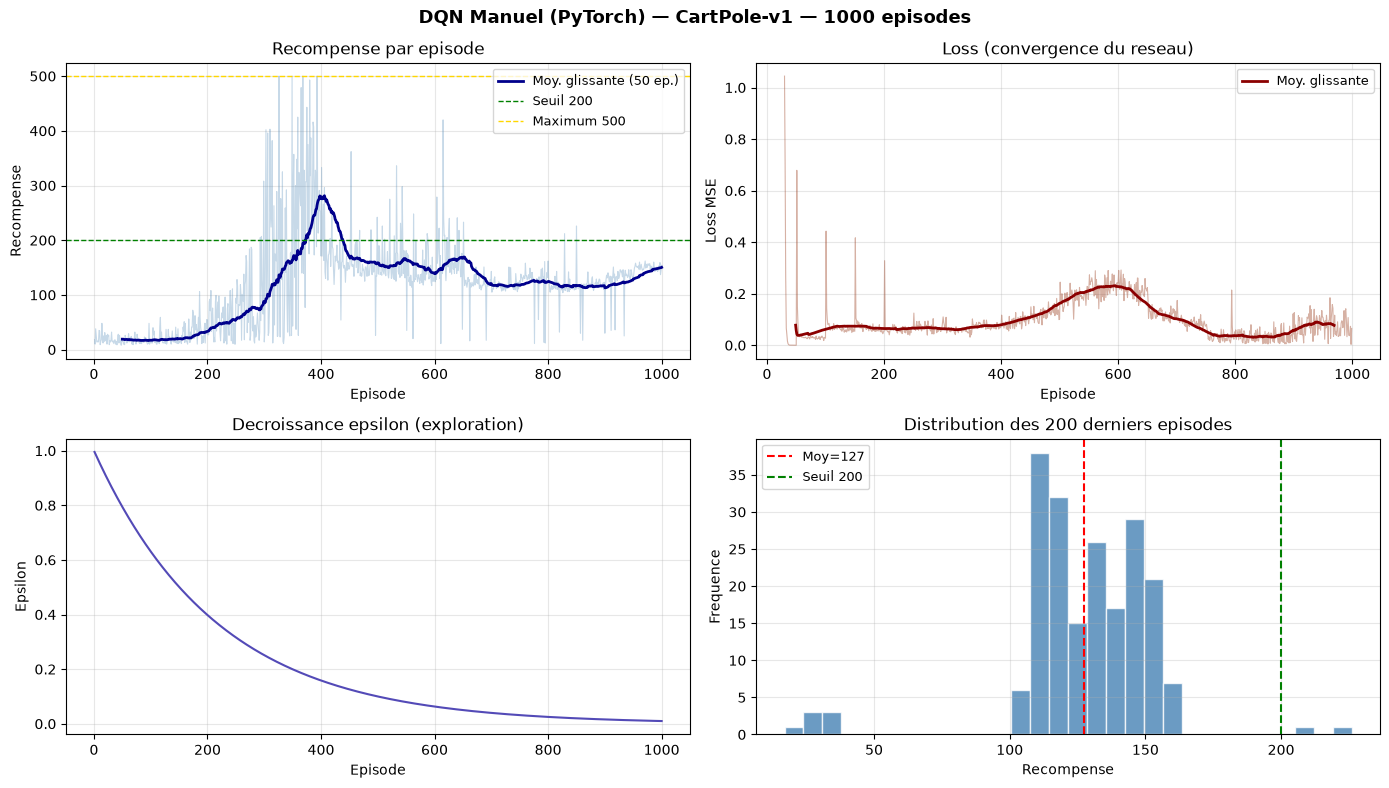

In [9]:
%matplotlib inline

print(f"  rewards_history......: {len(rewards_history)} éléments")
print(f"  losses_history.......: {len(losses_history)} éléments")
print(f"  eps_history..........: {len(eps_history)} éléments")
print(f"  N_EPISODES...........: {N_EPISODES}")
print(f"  rewards[:5]..........: {rewards_history[:5]}")
print(f"  rewards[-5:].........: {rewards_history[-5:]}")


fig_learning, axes = plt.subplots(2, 2, figsize=(14, 8))
fig_learning.suptitle(
    f'DQN Manuel (PyTorch) — CartPole-v1 — {N_EPISODES} episodes',
    fontsize=13, fontweight='bold')

episodes = np.arange(1, N_EPISODES+1)

# ── Recompense ────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(episodes, rewards_history,
         color='steelblue', alpha=0.3, linewidth=0.8)
roll = moving_average(rewards_history, WINDOW)
ax1.plot(range(WINDOW, N_EPISODES+1), roll,
         color='darkblue', linewidth=2,
         label=f'Moy. glissante ({WINDOW} ep.)')
ax1.axhline(200, color='green', lw=1, ls='--', label='Seuil 200')
ax1.axhline(500, color='gold',  lw=1, ls='--', label='Maximum 500')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Recompense')
ax1.set_title('Recompense par episode')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# ── Loss ──────────────────────────────────────────────────
ax2 = axes[0, 1]
nonzero_losses = [(i,l) for i,l in enumerate(losses_history) if l > 0]
if nonzero_losses:
    xs, ys = zip(*nonzero_losses)
    ax2.plot(xs, ys, color='#993C1D', alpha=0.4, linewidth=0.8)
    roll_l = moving_average(ys, min(WINDOW, len(ys)//2))
    ax2.plot(range(len(xs)-len(roll_l), len(xs)), roll_l,
             color='darkred', linewidth=2,
             label=f'Moy. glissante')
ax2.set_xlabel('Episode'); ax2.set_ylabel('Loss MSE')
ax2.set_title('Loss (convergence du reseau)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# ── Epsilon ───────────────────────────────────────────────
ax3 = axes[1, 0]
ax3.plot(episodes, eps_history, color='#534AB7', linewidth=1.5)
ax3.set_xlabel('Episode'); ax3.set_ylabel('Epsilon')
ax3.set_title('Decroissance epsilon (exploration)')
ax3.grid(True, alpha=0.3)

# ── Distribution finale ───────────────────────────────────
ax4 = axes[1, 1]
last200 = rewards_history[-200:]
ax4.hist(last200, bins=30, color='steelblue',
         edgecolor='white', alpha=0.8)
ax4.axvline(np.mean(last200), color='red', lw=1.5, ls='--',
            label=f'Moy={np.mean(last200):.0f}')
ax4.axvline(200, color='green', lw=1.5, ls='--', label='Seuil 200')
ax4.set_xlabel('Recompense'); ax4.set_ylabel('Frequence')
ax4.set_title('Distribution des 200 derniers episodes')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

plt.tight_layout()

# ── Sauvegarder la figure ─────────────────────────────────────
#fig_curves_path = MODELS / f"{nom_manual}_learning_curves.png"
#fig_learning.savefig(str(fig_curves_path), dpi=120, bbox_inches='tight')
#print(f"  Figure sauvegardée..: {fig_curves_path.name}")

# plt.show()

### Interpretation: Courbes DQN manuel

**Recompense :**
- Phase 0-100 ep. : exploration pure — recompenses faibles (~20-50)
- Phase 100-300 ep. : apprentissage — recompenses croissantes
- Phase 300+ ep. : convergence — recompenses stables > 200

**Loss :**
- Debut : loss elevee — le reseau ne sait rien
- Milieu : pic possible lors du remplissage du buffer
- Fin : loss stable et basse — convergence

**Points de vigilance DQN :**
- `MIN_BUFFER=500` : le reseau n'apprend pas avant d'avoir assez d'experiences
- `TARGET_UPDATE=20` : sync trop frequent → instabilite ; trop rare → lenteur
- `GAMMA=0.99` : horizon long — adapte a CartPole (episodes longs)

---
## Etape 3. Evaluation . DQN Manuel
Phase d'evaluation : **politique deterministe** (`argmax` sans exploration).
Le reseau est en mode `eval()` — dropout/batchnorm desactives si presents.

### [Cellule] 🔍 Evaluation . DQN Manuel

In [10]:
# ============================================================
# EVALUATION DQN MANUEL — 100 episodes
# ============================================================
# ── Passer le réseau en mode évaluation ──────────────────────
# En notre DQN, il n'y a ni Dropout ni BatchNorm — donc eval() et train()
# ne changent pas le résultat numériquement.
# Cependant, c'est une bonne pratique de l'inclure
policy_net.eval()

writer_eval = SummaryWriter(log_dir=str(LOGS_DQN_MAN_EVAL))

env_eval   = make_env('CartPole-v1', seed=SEED_EVAL)
eval_rewards_manual = []
eval_steps_manual   = []

with torch.no_grad():
    for ep in range(100):
        obs, _       = env_eval.reset()
        total_reward = 0.0
        n_steps      = 0
        terminated   = truncated = False

        while not (terminated or truncated):
            state         = torch.FloatTensor(obs).to(DEVICE)
            action        = policy_net(state).argmax().item()
            obs, reward, terminated, truncated, _ = env_eval.step(action)
            total_reward += reward
            n_steps      += 1

        eval_rewards_manual.append(total_reward)
        eval_steps_manual.append(n_steps)

        writer_eval.add_scalar('eval/ep_rew', total_reward, ep)

    writer_eval.add_scalar('eval/mean_reward', np.mean(eval_rewards_manual), 0)  # ✅
    writer_eval.add_scalar('eval/std_reward',  np.std(eval_rewards_manual),  0)  # ✅
    writer_eval.close()

env_eval.close()

stats_manual = compute_stats(eval_rewards_manual, eval_steps_manual)
print_stats(stats_manual,
            label='DQN Manuel -- 100 episodes -- CartPole-v1')
taux_manual = success_rate(eval_rewards_manual, threshold=200.0)
print(f'  Taux succes (>=200)..: {taux_manual:.1%}')
print()
if np.mean(eval_rewards_manual) >= 200:
    print('SUCCES DQN MANUEL : recompense moyenne >= 200')
else:
    print('A AMELIORER : augmenter N_EPISODES ou ajuster hyperparametres')

# reward_eval  = stats_manual['mean'] 
reward_eval  = np.mean(eval_rewards_manual)

nom_manual       = f"ex3_{ts}_dqn_manual_cartpole_{reward_finale:.0f}_{reward_eval:.0f}"


  DQN Manuel -- 100 episodes -- CartPole-v1
  Episodes............: 100
  Recompense moyenne..:  150.49  +-  3.98
  Recompense min/max..:  143.00  /   161.00
  Mediane.............:  151.00
  Q25 / Q75...........:  147.00  /   154.00
  Pas moyens..........:   150.5  +-  4.0
  Pas maximum.........:     161
  Taux succes (>=200)..: 0.0%

A AMELIORER : augmenter N_EPISODES ou ajuster hyperparametres


### Interpretation: Evaluation DQN Manuel

**Critere de succes CartPole :** recompense moyenne >= 200 sur 100 episodes.

| Recompense moyenne | Interpretation |
|---|---|
| < 100 | Agent pas encore convergé |
| 100 - 200 | Apprentissage en cours |
| 200 - 400 | Critere de succes atteint |
| > 400 | Agent excellent |
| 500 | Maximum possible — parfait |

**Comparaison avec la Q-table (Ex.2) :**
La Q-table etait impossible sur CartPole (espace continu).
Le DQN resout ce probleme en approximant Q(s,a) par un reseau neuronal.

### [Cellule] 💾 Sauvegarde DQN Manuel

In [11]:
# ============================================================
# SAUVEGARDER DQN MANUEL — policy_net + métadonnées
# ============================================================
import json

# ── Convertir numpy types → Python natifs ────────────────────
def to_serializable(obj):
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray):  return obj.tolist()
    return obj



# ── Sauvegarder les poids du policy_net ──────────────────────
torch.save(policy_net.state_dict(), str(manual_pth_path))

# ── Métadonnées ───────────────────────────────────────────────
metadata = {
    "reward_finale"   : round(float(reward_finale), 1),
    "taux_succes"     : round(sum(1 for r in rewards_history
                                  if r >= 200) / N_EPISODES, 3),
    
    "N_EPISODES"      : int(N_EPISODES),
    "TARGET_UPDATE"   : int(TARGET_UPDATE),
    "EPS_START"       : float(EPS_START),
    "EPS_END"         : float(EPS_END),
    "EPS_DECAY"       : round(float(EPS_DECAY), 6),
    "BUFFER_SIZE"     : int(BUFFER_SIZE),
    "MIN_BUFFER"      : int(MIN_BUFFER),
    "BATCH_SIZE"      : int(BATCH_SIZE),
    "LR"              : float(LR),
    "GAMMA"           : float(GAMMA),
    "obs_dim"         : int(obs_dim),
    "n_actions"       : int(n_actions),
    "mean_steps_real" : round(float(mean_steps_real), 1),
}
metadata = {k: to_serializable(v) for k, v in metadata.items()}

with open(manual_meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

# ── Vérification ──────────────────────────────────────────────
print("=" * 50)
print("SAUVEGARDE DQN MANUEL")
print("=" * 50)
print(f"  Fichier poids.......: {manual_pth_path.name}")
print(f"  Taille..............: "
      f"{manual_pth_path.stat().st_size // 1024} KB")
print(f"  Fichier meta........: {manual_meta_path.name}")
print(f"  Reward finale.......: {reward_finale:.1f}")
print(f"  Chemin complet......: {manual_pth_path}")
print("=" * 50)




# ── Sauvegarder la figure ─────────────────────────────────────
fig_path = MODELS / f"{nom_manual}_learning_curves.png"
fig_learning.savefig(str(fig_path), dpi=120, bbox_inches='tight')
# plt.close()

print(f"  Figure sauvegardée..: {fig_path.name}")


SAUVEGARDE DQN MANUEL
  Fichier poids.......: ex3_260621_001055_dqn_manual_cartpole_140.pth
  Taille..............: 71 KB
  Fichier meta........: ex3_260621_001055_dqn_manual_cartpole_140.json
  Reward finale.......: 139.6
  Chemin complet......: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\ex3_260621_001055_dqn_manual_cartpole_140.pth
  Figure sauvegardée..: ex3_260621_001055_dqn_manual_cartpole_140_150_learning_curves.png


---
### [Cellule] 🎥 Animation DQN Manuel en temps reel

Animation avec **3 panneaux** :
- **Gauche** : rendu visuel CartPole
- **Droite haut** : recompense cumulee
- **Droite bas** : Q-valeurs des 2 actions a chaque pas (bar chart)

In [12]:
# ============================================================
# ANIMATION DQN — CartPole + Q-values en temps reel
# ============================================================

def animate_dqn_episode(model, env_id='CartPole-v1', seed=SEED, max_steps=500):
    """Anime un episode du DQN avec Q-values en temps reel."""

    # Collecter la trajectoire
    env_anim    = gym.make(env_id, render_mode='rgb_array')
    obs, _      = env_anim.reset(seed=SEED)
    frames      = []
    rewards_cum = [0.0]
    q_vals_seq  = []
    actions_seq = []
    model.eval()

    terminated = truncated = False
    step = 0

    with torch.no_grad():
        while not (terminated or truncated) and step < max_steps:
            frames.append(env_anim.render())
            state  = torch.FloatTensor(obs).to(DEVICE)
            qv     = model(state).cpu().numpy()
            action = int(np.argmax(qv))
            q_vals_seq.append(qv)
            actions_seq.append(action)
            obs, reward, terminated, truncated, _ = env_anim.step(action)
            rewards_cum.append(rewards_cum[-1] + reward)
            step += 1

    env_anim.close()
    T = len(frames)

    # Construire la figure
    fig  = plt.figure(figsize=(14, 5))
    fig.suptitle(
        f'DQN Manuel — CartPole-v1 — {T} pas — reward={rewards_cum[-1]:.0f}',
        fontsize=12, fontweight='bold')
    gs   = gridspec.GridSpec(2, 2, width_ratios=[1.3, 1],
                              height_ratios=[1, 1], figure=fig,
                              hspace=0.45, wspace=0.35)
    ax_env  = fig.add_subplot(gs[:, 0])
    ax_rew  = fig.add_subplot(gs[0, 1])
    ax_qval = fig.add_subplot(gs[1, 1])

    ax_env.axis('off')
    img      = ax_env.imshow(frames[0])

    # Recompense
    line_r,  = ax_rew.plot([], [], color='#0F6E56', lw=2)
    point_r, = ax_rew.plot([], [], 'o', color='#0F6E56', ms=6)
    ax_rew.set_xlim(0, T+1)
    ax_rew.set_ylim(0, max(rewards_cum[-1]+10, 210))
    ax_rew.axhline(200, color='green', lw=0.8, ls='--', label='Seuil 200')
    ax_rew.set_xlabel('Pas', fontsize=9)
    ax_rew.set_ylabel('Recompense cumulee', fontsize=9)
    ax_rew.set_title('Recompense', fontsize=10)
    ax_rew.legend(fontsize=8); ax_rew.grid(True, alpha=0.3)

    # Q-values bar chart
    q_init = q_vals_seq[0]
    bars   = ax_qval.bar(['← 0 gauche', '→ 1 droite'],
                          q_init,
                          color=['#534AB7', '#BA7517'], alpha=0.85)
    ax_qval.set_ylim(min(0, q_init.min()-0.5),
                      max(q_init.max()+0.5, 1.0))
    ax_qval.set_ylabel('Q-valeur', fontsize=9)
    ax_qval.set_title('Q-valeurs actions (etat courant)', fontsize=10)
    ax_qval.grid(True, alpha=0.3, axis='y')
    txt_act = ax_qval.text(0.5, 0.92, '',
                            transform=ax_qval.transAxes,
                            ha='center', fontsize=9,
                            color='darkblue')

    # plt.tight_layout()

    plt.subplots_adjust(left=0.05, right=0.97,
                    top=0.88,  bottom=0.08,
                    hspace=0.45, wspace=0.35)

    def update(i):
        img.set_data(frames[i])
        xs = list(range(1, i+2))
        ys = rewards_cum[1:i+2]
        line_r.set_data(xs, ys)
        point_r.set_data([xs[-1]], [ys[-1]])
        qv = q_vals_seq[i]
        for bar, v in zip(bars, qv):
            bar.set_height(v)
        ax_qval.set_ylim(min(0, qv.min()-0.5), qv.max()+0.5)
        arr = '← gauche' if actions_seq[i]==0 else '→ droite'
        txt_act.set_text(f'Action choisie : {arr}')
        return [img, line_r, point_r, txt_act] + list(bars)

    anim = animation.FuncAnimation(
        fig, update, frames=T, interval=40, blit=True)
    plt.close()
    # return HTML(anim.to_html5_video())
    return anim


# anim_sb3 = animate_sb3_episode(model_sb3, seed=SEED)
# display(anim_sb3)

anim_manual      = animate_dqn_episode(policy_net, seed=SEED)
anim_manual_html = HTML(anim_manual.to_html5_video())

display(anim_manual_html)

### [Cellule] 💾 Animation. Sauvegarder 

In [13]:
# ── Sauvegarder la vidéo DQN Manuel ──────────────────────────
nom_anim_manual      = f"{nom_manual}_animation"
anim_manual_path_mp4 = MODELS / f"{nom_anim_manual}.mp4"
anim_manual_path_gif = MODELS / f"{nom_anim_manual}.gif"

try:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter(fps=30, bitrate=1800)
    anim_manual.save(str(anim_manual_path_mp4), writer=writer)
    print(f"  MP4 sauvegardé.....: {anim_manual_path_mp4.name}")
    print(f"  Taille..............: "
          f"{anim_manual_path_mp4.stat().st_size // 1024} KB")
except Exception as e:
    from matplotlib.animation import PillowWriter
    print(f"  FFMpeg non disponible : {e}")
    writer = PillowWriter(fps=25)
    anim_manual.save(str(anim_manual_path_gif), writer=writer)
    print(f"  GIF sauvegardé.....: {anim_manual_path_gif.name}")
    print(f"  Taille..............: "
          f"{anim_manual_path_gif.stat().st_size // 1024} KB")

  MP4 sauvegardé.....: ex3_260621_001055_dqn_manual_cartpole_140_150_animation.mp4
  Taille..............: 266 KB


### Interpretation: Animation DQN Manuel

**Ce qu'on observe :**
- Le mât reste debout longtemps → l'agent a appris a equilibrer
- Les Q-valeurs alternent entre les deux actions selon l'angle du mat
- La recompense cumulee monte lineairement (+1 a chaque pas)

**Les Q-valeurs revelent la politique :**
- Quand le mat penche a droite → Q(gauche) > Q(droite) → action 0
- Quand le mat penche a gauche → Q(droite) > Q(gauche) → action 1
- L'ecart entre les deux Q-valeurs = confiance de l'agent

---
# PARTIE 2. DQN avec Stable-Baselines3

SB3 implemente le DQN en production — meme algorithme mais :
- Buffer plus grand, optimisations memoire
- Logs TensorBoard integres
- `evaluate_policy` standardise
- Sauvegarde/chargement `.zip`

**Comparaison avec le DQN manuel :**

| | DQN Manuel | DQN SB3 |
|---|---|---|
| Lignes de code | ~100 | ~10 |
| Flexibilite | Totale | Parametres |
| Performance | Bonne | Optimisee |
| Usage | Pedagogique | Production |


---
## Etape 4. DQN Stable-Baselines3

On entraine, evalue et sauvegarde un agent DQN SB3 sur CartPole-v1.

**`total_timesteps`** = nombre total d'interactions avec l'environnement
(pas le nombre d'episodes — CartPole dure ~200 pas par episode en moyenne).

### [Cellule] 🛠️ Hyperparametres SB3

In [14]:
# ===================================================================
# TOTAL_STEPS         = int(N_EPISODES * mean_steps_real)
# TOTAL_TIMESTEPS_SB3 = N_EPISODES * int(mean_steps_real)
# TARGET_UPDATE_SB3   = int(TARGET_UPDATE * mean_steps_real)

print("=" * 60)
print("SB3 — CONVERSIONS HYPERPARAMÈTRES")
print("=" * 60)

# Estimation 200 pas/épisode avant d'avoir mean_steps_real
# Sera recalculé après entraînement avec la valeur réelle
TOTAL_STEPS         = N_EPISODES * 200
TOTAL_TIMESTEPS_SB3 = TOTAL_STEPS
print(f"  TOTAL_STEPS...........: {TOTAL_STEPS:,}"
      f"  ({N_EPISODES} ep × 200 pas estimés)")

print("─" * 60)

BUFFER_SIZE_SB3     = BUFFER_SIZE
print(f"  BUFFER_SIZE_SB3.......: {BUFFER_SIZE_SB3:,}")

print("─" * 60)

# TARGET_UPDATE en épisodes → steps (200 pas/ep estimés)
# Réduit à 2000 pour un target network plus frais
TARGET_UPDATE_SB3   = 2_000
print(f"  TARGET_UPDATE_SB3.....: {TARGET_UPDATE_SB3:,}"
      f"  (réduit de {TARGET_UPDATE * 200:,} → 2000 steps)")

print("─" * 60)

# Réduit de 0.46 → 0.20 : epsilon atteint 0.01 plus tôt
# → plus d'épisodes en mode exploitation pour affiner la politique
EXPLORATION_FRAC    = 0.20
print(f"  EXPLORATION_FRAC......: {EXPLORATION_FRAC}"
      f"  (equiv. EPS_DECAY={EPS_DECAY:.6f})")

print("─" * 60)
print(f"  Résumé modifications  :")
print(f"    TARGET_UPDATE_SB3...: {TARGET_UPDATE * 200:,} → {TARGET_UPDATE_SB3:,}  (−{TARGET_UPDATE * 200 - TARGET_UPDATE_SB3:,} steps)")
print(f"    EXPLORATION_FRAC....: 0.46 → {EXPLORATION_FRAC}  (exploration plus courte)")
print("=" * 60)

# ── Conversions SB3 ──────────────────────────────────────────
print()
print("  -- Conversions SB3 -------------------------------------")
print(f"  TOTAL_TIMESTEPS_SB3...: {TOTAL_TIMESTEPS_SB3:,}"
      f"  ({N_EPISODES} ep × {mean_steps_real:.0f} pas)")
print(f"  TARGET_UPDATE_SB3.....: {TARGET_UPDATE_SB3:,}"
      f"  ({TARGET_UPDATE} ep × {mean_steps_real:.0f} pas)")
print(f"  EXPLORATION_FRAC......: {0.46}"
      f"  (equiv. EPS_DECAY={EPS_DECAY:.6f})")
print("=" * 55)


SB3 — CONVERSIONS HYPERPARAMÈTRES
  TOTAL_STEPS...........: 200,000  (1000 ep × 200 pas estimés)
────────────────────────────────────────────────────────────
  BUFFER_SIZE_SB3.......: 21,728
────────────────────────────────────────────────────────────
  TARGET_UPDATE_SB3.....: 2,000  (réduit de 10,000 → 2000 steps)
────────────────────────────────────────────────────────────
  EXPLORATION_FRAC......: 0.2  (equiv. EPS_DECAY=0.995405)
────────────────────────────────────────────────────────────
  Résumé modifications  :
    TARGET_UPDATE_SB3...: 10,000 → 2,000  (−8,000 steps)
    EXPLORATION_FRAC....: 0.46 → 0.2  (exploration plus courte)

  -- Conversions SB3 -------------------------------------
  TOTAL_TIMESTEPS_SB3...: 200,000  (1000 ep × 117 pas)
  TARGET_UPDATE_SB3.....: 2,000  (50 ep × 117 pas)
  EXPLORATION_FRAC......: 0.46  (equiv. EPS_DECAY=0.995405)


### [Cellule] 🏋️‍♀️ Entrainement (LEARN)

In [15]:
# ============================================================
# DQN STABLE-BASELINES3
# ============================================================
from stable_baselines3                  import DQN as DQN_SB3
from stable_baselines3.common.evaluation import evaluate_policy

from stable_baselines3.common.callbacks  import (
    EvalCallback,
    StopTrainingOnRewardThreshold,
)

from stable_baselines3.common.monitor import Monitor
import os

# Créer un dossier pour les logs si nécessaire
os.makedirs("logs_sb3", exist_ok=True)

# Environnement d'entrainement
env_sb3  = gym.make('CartPole-v1')
env_sb3 = Monitor(env_sb3, "logs_sb3/monitor.csv")

"""
# Instancier le modele DQN SB3
model_sb3 = DQN(
    'MlpPolicy',
    env_sb3,
    learning_rate          = 1e-3,
    buffer_size            = 50_000,
    learning_starts        = 1_000,
    batch_size             = 64,
    gamma                  = 0.99,
    target_update_interval = 500,
    exploration_fraction   = 0.3,
    exploration_final_eps  = 0.01,
    verbose                = 1,
    tensorboard_log        = './logs_sb3/'
)
"""

model_sb3 = DQN_SB3(
    'MlpPolicy',
    env_sb3,

    # ── Aprendizaje ──────────────────────────────────────────
    learning_rate          = LR,           # 5e-4
    gamma                  = GAMMA,        # 0.99
    batch_size             = BATCH_SIZE,   # 64

    # ── Replay buffer ─────────────────────────────────────────
    buffer_size            = BUFFER_SIZE_SB3,  # 10_000
    learning_starts        = MIN_BUFFER,       # 1_000

    # ── Target network ────────────────────────────────────────
    # Converion no trivial. TARGET_UPDATE = 50
    # Manual  : TARGET_UPDATE = 50 episodios
    # SB3     : target_update_interval en STEPS
    # 50 episodios × 200 pasos/episodio = 10_000 steps
    target_update_interval = TARGET_UPDATE_SB3,

    # ── Exploration ───────────────────────────────────────────
    # Converion no trivial. EPS_DECAY     = 0.998
    # EPS_DECAY:  par épisode → fraction de steps

    # Manuel : epsilon *= 0.998 à chaque épisode        atteint 0.01 à l'épisode ~460
    # SB3    : exploration_fraction = fraction du total_timesteps
    #          0.01 atteint à 460/1000 = 0.46
    #          → exploration_fraction = 0.46

    exploration_fraction   = EXPLORATION_FRAC,   # ← ver nota abajo
    exploration_final_eps  = EPS_END,            # 0.01

    # ── Logs ──────────────────────────────────────────────────
    verbose                = 0,
    tensorboard_log        = LOGS_DQN_SB3_TRAIN # './logs/ex3_{ts}_logs_sb3/' 
)

print('Architecture SB3 :')
print(model_sb3.policy)

# ============================================================
# HYPERPARAMETRES — tableau de bord comparatif Manuel / SB3
# ============================================================
print(f"+---------------+----------+------------------+----------+--------------+----------+")
print(f"|               |  Manuel  |                  |  Manuel  |              |  Manuel  |")
print(f"|               |  SB3     |                  |  SB3     |              |  SB3     |")
print(f"+---------------+----------+------------------+----------+--------------+----------+")
print(f"| EPS_START     | {EPS_START:<8} | EPS_DECAY        | {EPS_DECAY:<8.6f} | BUFFER_SIZE  | {BUFFER_SIZE:<8,} |")
print(f"|               | {EPS_START:<8} | exploration_frac | {EXPLORATION_FRAC:<8} |              | {BUFFER_SIZE_SB3:<8,} |")
print(f"+---------------+----------+------------------+----------+--------------+----------+")
print(f"| EPS_END       | {EPS_END:<8} |                  |          | MIN_BUFFER   | {MIN_BUFFER:<8,} |")
print(f"| expl_final_eps| {EPS_END:<8} |                  |          | learning_st. | {MIN_BUFFER:<8,} |")
print(f"+---------------+----------+------------------+----------+--------------+----------+")
print(f"| TARGET_UPDATE | {TARGET_UPDATE:<8} | N_EPISODES       | {N_EPISODES:<8} | BATCH_SIZE   | {BATCH_SIZE:<8} |")
print(f"| target_upd.   | {TARGET_UPDATE_SB3:<8,} | total_timesteps  | {TOTAL_STEPS:<8,} |              | {BATCH_SIZE:<8} |")
print(f"+---------------+----------+------------------+----------+--------------+----------+")
print(f"|               |          | LR               | {LR:<8} | GAMMA        | {GAMMA:<8} |")
print(f"|               |          |                  | {LR:<8} |              | {GAMMA:<8} |")
print(f"+---------------+----------+------------------+----------+--------------+----------+")

# Entrainement
print('\nEntrainement SB3 en cours...')
"""
model_sb3.learn(
    total_timesteps=50_000,
    progress_bar=True
    )
"""
model_sb3.learn(
    total_timesteps = TOTAL_TIMESTEPS_SB3 ,
    progress_bar    = True
)

print('Entrainement SB3 termine.')

Architecture SB3 :
DQNPolicy(
  (q_net): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)
+---------------+----------+------------------+----------+--------------+----------+
|               |  Manuel  |                  |  Manuel  |              |  Manuel  |
|               |  SB3     |           

Output()

Entrainement SB3 termine.


### [Cellule] 🔍 Evaluation (evaluate_policy)

In [16]:
# ============================================================
# EVALUATION SB3 — 100 episodes
# ============================================================
env_eval_sb3 = gym.make('CartPole-v1')

eval_callback = EvalCallback(
    env_eval_sb3,
    log_path             = str(LOGS_DQN_SB3_EVAL),   # ← ici
    eval_freq            = 5_000,                      # toutes les 5k steps
    n_eval_episodes      = 20,
    deterministic        = True,
    render               = False,
    verbose              = 0
)

mean_reward_sb3, std_reward_sb3 = evaluate_policy(
    model_sb3,
    env_eval_sb3,
    n_eval_episodes = 100,
    deterministic   = True,
    render          = False
)

env_eval_sb3.close()

print('=' * 50)
print('EVALUATION DQN SB3')
print('=' * 50)
print(f'  Recompense moyenne..: {mean_reward_sb3:.1f}')
print(f'  Ecart-type..........: {std_reward_sb3:.1f}')
print()
if mean_reward_sb3 >= 200:
    print(f'SUCCES SB3 : {mean_reward_sb3:.1f} >= 200')
else:
    print(f'A AMELIORER : {mean_reward_sb3:.1f} < 200')



C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\.venv\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


EVALUATION DQN SB3
  Recompense moyenne..: 124.5
  Ecart-type..........: 6.2

A AMELIORER : 124.5 < 200


### Interpretation: DQN SB3

**`learning_starts=1000`** : SB3 remplit d'abord le buffer avec des actions
aleatoires avant de commencer a apprendre — equivalent a `MIN_BUFFER`.

**`exploration_fraction=0.3`** : epsilon decroit sur les 30% premiers
timesteps (15 000 sur 50 000) — equivalent a `EPS_DECAY`.

**`target_update_interval=500`** : sync du target_net tous les 500 steps
(SB3 compte en steps, pas en episodes).

> **SB3 vs Manuel :** les deux implementent le meme algorithme DQN.
> SB3 converge generalement plus vite car son buffer est plus grand
> et ses optimisations internes sont plus poussees.

### [Cellule] 🔍 Evaluation. (Boucle explicite pour metriques detaillees)

In [17]:
# ============================================================
# EVALUATION SB3 — boucle explicite pour metriques detaillees
# ============================================================
env_eval_sb3 = gym.make('CartPole-v1')
eval_rewards_sb3 = []
eval_steps_sb3   = []

for ep in range(100):
    obs, _       = env_eval_sb3.reset()
    total_reward = 0.0
    n_steps      = 0
    terminated   = truncated = False

    while not (terminated or truncated):
        # model.predict — equivalent policy_net.eval() + argmax
        action, _ = model_sb3.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env_eval_sb3.step(action)
        total_reward += reward
        n_steps      += 1

    eval_rewards_sb3.append(total_reward)
    eval_steps_sb3.append(n_steps)

env_eval_sb3.close()

# Statistiques
stats_sb3 = compute_stats(eval_rewards_sb3, eval_steps_sb3)
print_stats(stats_sb3,
            label='DQN SB3 -- 100 episodes -- CartPole-v1')
taux_sb3 = success_rate(eval_rewards_sb3, threshold=200.0)
print(f'  Taux succes (>=200)..: {taux_sb3:.1%}')
print()
if np.mean(eval_rewards_sb3) >= 200:
    print('SUCCES SB3 : recompense moyenne >= 200')
else:
    print('A AMELIORER : recompense moyenne < 200')

# ── Nom du fichier avec score ─────────────────────────────────
nom_sb3       = f"ex3_{ts}_dqn_sb3_cartpole_{mean_reward_sb3:.0f}"




  DQN SB3 -- 100 episodes -- CartPole-v1
  Episodes............: 100
  Recompense moyenne..:  124.33  +-  6.16
  Recompense min/max..:  113.00  /   142.00
  Mediane.............:  124.00
  Q25 / Q75...........:  119.75  /   128.00
  Pas moyens..........:   124.3  +-  6.2
  Pas maximum.........:     142
  Taux succes (>=200)..: 0.0%

A AMELIORER : recompense moyenne < 200


### [Cellule] 📈 Graphiques pour SB3

  Figure sauvegardée..: ex3_260621_001055_dqn_sb3_cartpole_124_learning_curves.png


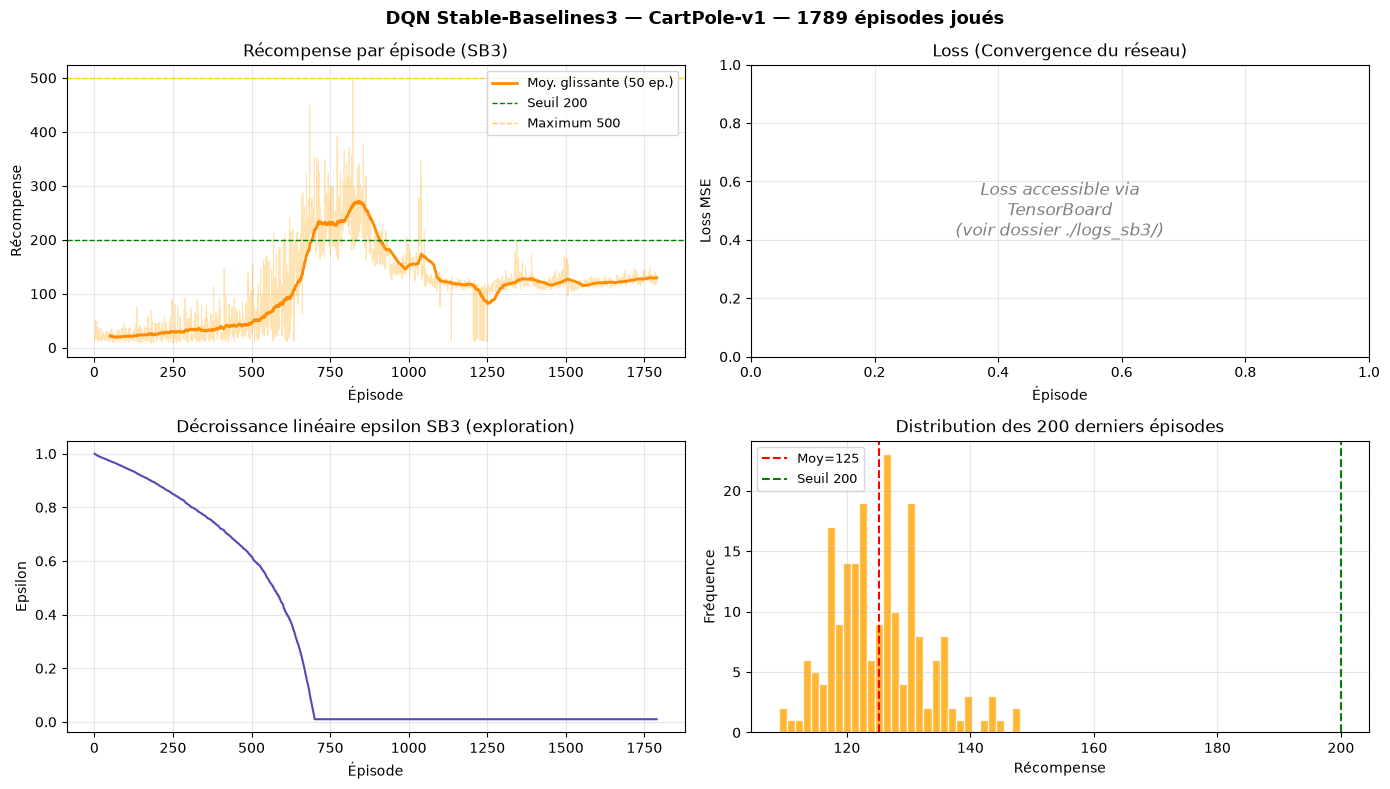

In [18]:
# 1. Charger les données du Monitor SB3
log_dir = "logs_sb3/monitor.csv"
df = pd.read_csv(log_dir, skiprows=1)

rewards_history_sb3 = df['r'].tolist()
lengths_history_sb3 = df['l'].tolist()
timesteps_history = np.cumsum(lengths_history_sb3) # Pas cumulés pour l'epsilon
n_episodes_actual = len(rewards_history_sb3)

WINDOW = 50
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    f'DQN Stable-Baselines3 — CartPole-v1 — {n_episodes_actual} épisodes joués',
    fontsize=13, fontweight='bold')

episodes = np.arange(1, n_episodes_actual + 1)

# Function moving_average (assumée définie dans ton notebook)
# def moving_average(data, window): return np.convolve(data, np.ones(window)/window, mode='valid')

# ── 1. Récompense par épisode ────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(episodes, rewards_history_sb3, color='orange', alpha=0.3, linewidth=0.8)
roll = moving_average(rewards_history_sb3, min(WINDOW, n_episodes_actual))
ax1.plot(range(len(rewards_history_sb3) - len(roll) + 1, len(rewards_history_sb3) + 1), roll,
         color='darkorange', linewidth=2, label=f'Moy. glissante ({WINDOW} ep.)')
ax1.axhline(200, color='green', lw=1, ls='--', label='Seuil 200')
ax1.axhline(500, color='gold',  lw=1, ls='--', label='Maximum 500')
ax1.set_xlabel('Épisode'); ax1.set_ylabel('Récompense')
ax1.set_title('Récompense par épisode (SB3)')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# ── 2. Note sur la Loss (Limitation SB3) ──────────────────────────────────
ax2 = axes[0, 1]
# SB3 n'expose pas facilement la loss par épisode sans callback Tensorboard.
# On affiche un texte explicatif ou une courbe vide propre.
ax2.text(0.5, 0.5, "Loss accessible via\nTensorBoard\n(voir dossier ./logs_sb3/)",
         horizontalalignment='center', verticalalignment='center',
         fontsize=12, color='gray', style='italic', transform=ax2.transAxes)
ax2.set_xlabel('Épisode'); ax2.set_ylabel('Loss MSE')
ax2.set_title('Loss (Convergence du réseau)')
ax2.grid(True, alpha=0.3)

# ── 3. Décroissance Epsilon ───────────────────────────────────────────────
ax3 = axes[1, 0]
# Recalcul de l'epsilon SB3 basé sur les timesteps totaux
total_steps_limit = N_EPISODES * 200
end_exploration_step = EXPLORATION_FRAC * total_steps_limit

eps_history_sb3 = []
for step in timesteps_history:
    if step >= end_exploration_step:
        eps = EPS_END
    else:
        # Décroissance linéaire de SB3 (de EPS_START à EPS_END)
        eps = EPS_START - (step / end_exploration_step) * (EPS_START - EPS_END)
    eps_history_sb3.append(max(eps, EPS_END))

ax3.plot(episodes, eps_history_sb3, color='#534AB7', linewidth=1.5)
ax3.set_xlabel('Épisode'); ax3.set_ylabel('Epsilon')
ax3.set_title('Décroissance linéaire epsilon SB3 (exploration)')
ax3.grid(True, alpha=0.3)

# ── 4. Distribution finale ───────────────────────────────────
ax4 = axes[1, 1]
last200 = rewards_history_sb3[-200:] if n_episodes_actual >= 200 else rewards_history_sb3
ax4.hist(last200, bins=30, color='orange', edgecolor='white', alpha=0.8)
ax4.axvline(np.mean(last200), color='red', lw=1.5, ls='--',
            label=f'Moy={np.mean(last200):.0f}')
ax4.axvline(200, color='green', lw=1.5, ls='--', label='Seuil 200')
ax4.set_xlabel('Récompense'); ax4.set_ylabel('Fréquence')
ax4.set_title(f'Distribution des {len(last200)} derniers épisodes')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

plt.tight_layout()

# ── Sauvegarder la figure SB3 ─────────────────────────────────
fig_sb3_path = MODELS / f"{nom_sb3}_learning_curves.png"
fig.savefig(str(fig_sb3_path), dpi=120, bbox_inches='tight')
print(f"  Figure sauvegardée..: {fig_sb3_path.name}")

plt.show()

### [Cellule] 💾 Sauvegarder model_sb3

In [19]:
# ============================================================
# SAUVEGARDER DQN SB3 — modele + métadonnées
# ============================================================
import json

# ── Convertir numpy types → Python natifs ────────────────────
def to_serializable(obj):
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray):  return obj.tolist()
    return obj

sb3_save_path = MODELS / nom_sb3
sb3_meta_path = MODELS / f"{nom_sb3}.json"

# ── Sauvegarder le modele SB3 ─────────────────────────────────
model_sb3.save(str(sb3_save_path))

# ── Métadonnées SB3 ───────────────────────────────────────────
metadata_sb3 = {
    # ── Résultats ─────────────────────────────────────────────
    "reward_finale"        : round(float(mean_reward_sb3), 1),
    "std_reward"           : round(float(std_reward_sb3), 1),
    "taux_succes"          : round(sum(1 for r in eval_rewards_sb3
                                       if r >= 200) / 100, 3),
    # ── Paramètres SB3 ────────────────────────────────────────
    "TOTAL_TIMESTEPS_SB3"  : int(TOTAL_TIMESTEPS_SB3),
    "TARGET_UPDATE_SB3"    : int(TARGET_UPDATE_SB3),
    "EXPLORATION_FRAC"     : float(EXPLORATION_FRAC),
    "BUFFER_SIZE_SB3"      : int(BUFFER_SIZE_SB3),
    # ── Paramètres communs ────────────────────────────────────
    "EPS_START"            : float(EPS_START),
    "EPS_END"              : float(EPS_END),
    "BATCH_SIZE"           : int(BATCH_SIZE),
    "LR"                   : float(LR),
    "GAMMA"                : float(GAMMA),
    "obs_dim"              : int(obs_dim),
    "n_actions"            : int(n_actions),
    # ── Référence Manuel ──────────────────────────────────────
    "equiv_N_EPISODES"     : int(N_EPISODES),
    "equiv_EPS_DECAY"      : round(float(EPS_DECAY), 6),
    "equiv_TARGET_UPDATE"  : int(TARGET_UPDATE),
    "equiv_MIN_BUFFER"     : int(MIN_BUFFER),
    "equiv_BUFFER_SIZE"    : int(BUFFER_SIZE),
}
metadata_sb3 = {k: to_serializable(v) for k, v in metadata_sb3.items()}

with open(sb3_meta_path, 'w') as f:
    json.dump(metadata_sb3, f, indent=2)

# ── Vérification ──────────────────────────────────────────────
print("=" * 50)
print("SAUVEGARDE DQN SB3")
print("=" * 50)
print(f"  Fichier modele......: {sb3_save_path.name}.zip")
print(f"  Taille..............: "
      f"{(Path(str(sb3_save_path) + '.zip')).stat().st_size // 1024} KB")
print(f"  Fichier meta........: {sb3_meta_path.name}")
print(f"  Reward finale.......: {mean_reward_sb3:.1f}")
print(f"  Ecart-type..........: {std_reward_sb3:.1f}")
print(f"  Chemin complet......: {sb3_save_path}.zip")
print("=" * 50)


SAUVEGARDE DQN SB3
  Fichier modele......: ex3_260621_001055_dqn_sb3_cartpole_124.zip
  Taille..............: 97 KB
  Fichier meta........: ex3_260621_001055_dqn_sb3_cartpole_124.json
  Reward finale.......: 124.5
  Ecart-type..........: 6.2
  Chemin complet......: C:\Users\Public\IAE_DELL\pra_dell\m11_ocr\models\ex3_260621_001055_dqn_sb3_cartpole_124.zip


# PARTIE 3. Comparaison DQN Manuel vs SB3

---
### [Cellule] Visualisation. Comparaison DQN Manuel vs SB3

Comparaison directe des deux implementations sur 100 episodes d'evaluation.

                          DQN Manuel       DQN SB3
  Recompense moyenne           150.5         124.8
  Ecart-type                     4.0           5.7
  Minimum                        143           115
  Maximum                        161           142
  Taux succes >=200            0.0%         0.0%


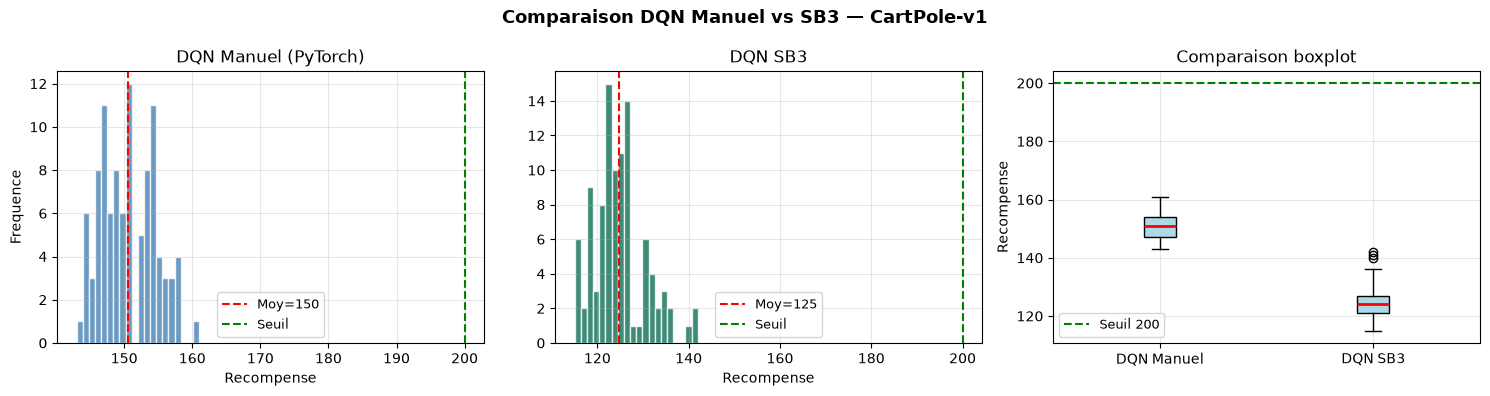

In [20]:
# ============================================================
# COMPARAISON VISUELLE DQN MANUEL vs SB3
# ============================================================

# Collecter les rewards SB3
env_cmp   = gym.make('CartPole-v1')
eval_rewards_sb3 = []

with torch.no_grad():
    for _ in range(100):
        obs, _ = env_cmp.reset()
        total  = 0.0
        done   = trunc = False
        while not (done or trunc):
            action, _ = model_sb3.predict(obs, deterministic=True)
            obs, r, done, trunc, _ = env_cmp.step(action)
            total += r
        eval_rewards_sb3.append(total)
env_cmp.close()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparaison DQN Manuel vs SB3 — CartPole-v1',
             fontsize=13, fontweight='bold')

# Histogramme Manuel
axes[0].hist(eval_rewards_manual, bins=20,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(eval_rewards_manual),
                color='red', lw=1.5, ls='--',
                label=f'Moy={np.mean(eval_rewards_manual):.0f}')
axes[0].axvline(200, color='green', lw=1.5, ls='--', label='Seuil')
axes[0].set_title('DQN Manuel (PyTorch)')
axes[0].set_xlabel('Recompense'); axes[0].set_ylabel('Frequence')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Histogramme SB3
axes[1].hist(eval_rewards_sb3, bins=20,
             color='#0F6E56', edgecolor='white', alpha=0.8)
axes[1].axvline(np.mean(eval_rewards_sb3),
                color='red', lw=1.5, ls='--',
                label=f'Moy={np.mean(eval_rewards_sb3):.0f}')
axes[1].axvline(200, color='green', lw=1.5, ls='--', label='Seuil')
axes[1].set_title('DQN SB3')
axes[1].set_xlabel('Recompense')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# Boxplot comparatif
axes[2].boxplot([eval_rewards_manual, eval_rewards_sb3],
                tick_labels=['DQN Manuel', 'DQN SB3'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', lw=2))
axes[2].axhline(200, color='green', lw=1.5, ls='--', label='Seuil 200')
axes[2].set_ylabel('Recompense')
axes[2].set_title('Comparaison boxplot')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.show()

# Tableau recapitulatif
print('=' * 55)
print(f'  {"":20}  {"DQN Manuel":>12}  {"DQN SB3":>12}')
print('=' * 55)
print(f'  {"Recompense moyenne":20}  {np.mean(eval_rewards_manual):>12.1f}  {np.mean(eval_rewards_sb3):>12.1f}')
print(f'  {"Ecart-type":20}  {np.std(eval_rewards_manual):>12.1f}  {np.std(eval_rewards_sb3):>12.1f}')
print(f'  {"Minimum":20}  {np.min(eval_rewards_manual):>12.0f}  {np.min(eval_rewards_sb3):>12.0f}')
print(f'  {"Maximum":20}  {np.max(eval_rewards_manual):>12.0f}  {np.max(eval_rewards_sb3):>12.0f}')
print(f'  {"Taux succes >=200":20}  {success_rate(eval_rewards_manual,200):>11.1%}  {success_rate(eval_rewards_sb3,200):>11.1%}')
print('=' * 55)

---
### [Cellule] 🎥 Animation DQN SB3 en temps reel

In [21]:
# Animation SB3 — reutiliser animate_dqn_episode
# avec un wrapper pour la prediction SB3

def animate_sb3_episode(model_sb3, env_id='CartPole-v1',  seed=SEED, max_steps=500):
    env_anim    = gym.make(env_id, render_mode='rgb_array')
    obs, _      = env_anim.reset(seed=SEED)
    frames      = []
    rewards_cum = [0.0]
    actions_seq = []
    terminated  = truncated = False
    step = 0

    while not (terminated or truncated) and step < max_steps:
        frames.append(env_anim.render())
        action, _ = model_sb3.predict(obs, deterministic=True)
        actions_seq.append(int(action))
        obs, reward, terminated, truncated, _ = env_anim.step(action)
        rewards_cum.append(rewards_cum[-1] + reward)
        step += 1

    env_anim.close()
    T = len(frames)

    fig  = plt.figure(figsize=(12, 4))
    fig.suptitle(
        f'DQN SB3 — CartPole-v1 — {T} pas — reward={rewards_cum[-1]:.0f}',
        fontsize=12, fontweight='bold')
    gs   = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1], figure=fig)
    ax_env = fig.add_subplot(gs[0])
    ax_rew = fig.add_subplot(gs[1])

    ax_env.axis('off')
    img     = ax_env.imshow(frames[0])
    line_r, = ax_rew.plot([], [], color='#0F6E56', lw=2)
    point_r,= ax_rew.plot([], [], 'o', color='#0F6E56', ms=6)
    ax_rew.set_xlim(0, T+1)
    ax_rew.set_ylim(0, max(rewards_cum[-1]+10, 210))
    ax_rew.axhline(200, color='green', lw=0.8, ls='--', label='Seuil 200')
    ax_rew.set_xlabel('Pas', fontsize=9)
    ax_rew.set_ylabel('Recompense cumulee', fontsize=9)
    ax_rew.set_title('Recompense en temps reel', fontsize=10)
    ax_rew.legend(fontsize=8); ax_rew.grid(True, alpha=0.3)
    txt = ax_env.text(0.02, 0.04, '', transform=ax_env.transAxes,
                      fontsize=9, color='white',
                      bbox=dict(facecolor='black', alpha=0.5, pad=3),
                      verticalalignment='bottom')
    plt.tight_layout()

    def update(i):
        img.set_data(frames[i])
        xs = list(range(1, i+2))
        ys = rewards_cum[1:i+2]
        line_r.set_data(xs, ys); point_r.set_data([xs[-1]], [ys[-1]])
        arr = '← gauche' if actions_seq[i]==0 else '→ droite'
        txt.set_text(f'Pas {i+1}  |  {arr}')
        return img, line_r, point_r, txt

    anim = animation.FuncAnimation(
        fig, update, frames=T, interval=40, blit=True)
    plt.close()
    # return HTML(anim.to_html5_video())
    return anim


# anim_sb3 = animate_sb3_episode(model_sb3, seed=SEED)
# display(anim_sb3)

anim_sb3      = animate_sb3_episode(model_sb3, seed=SEED)
anim_sb3_html = HTML(anim_sb3.to_html5_video())

display(anim_sb3_html)

### [Cellule] 💾 Animation. Sauvegarder 

In [22]:
# ── Sauvegarder la vidéo SB3 ─────────────────────────────────
nom_anim_sb3      = f"{nom_sb3}_animation"
anim_sb3_path_mp4 = MODELS / f"{nom_anim_sb3}.mp4"
anim_sb3_path_gif = MODELS / f"{nom_anim_sb3}.gif"

try:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter(fps=30, bitrate=1800)
    anim_sb3.save(str(anim_sb3_path_mp4), writer=writer)
    print(f"  MP4 sauvegardé.....: {anim_sb3_path_mp4.name}")
    print(f"  Taille..............: "
          f"{anim_sb3_path_mp4.stat().st_size // 1024} KB")
except Exception as e:
    from matplotlib.animation import PillowWriter
    print(f"  FFMpeg non disponible : {e}")
    writer = PillowWriter(fps=25)
    anim_sb3.save(str(anim_sb3_path_gif), writer=writer)
    print(f"  GIF sauvegardé.....: {anim_sb3_path_gif.name}")
    print(f"  Taille..............: "
          f"{anim_sb3_path_gif.stat().st_size // 1024} KB")

  MP4 sauvegardé.....: ex3_260621_001055_dqn_sb3_cartpole_124_animation.mp4
  Taille..............: 143 KB


---
## Conclusion. Exercice 3

**Ce que nous avons appris :**

1. **DQN = Q-Learning + Reseau Neuronal**
   - Remplace la Q-table (discrete) par un reseau (continu)
   - Permet de traiter des espaces d'etats infinis

2. **Experience Replay**
   - Buffer circulaire `deque(maxlen=N)`
   - Mini-batches aleatoires → brise les correlations temporelles

3. **Target Network**
   - Copie gelee du policy_net
   - Sync periodique → stabilise les cibles TD

4. **SB3 = DQN professionnel**
   - Meme algorithme, implementation optimisee
   - `model.learn()` + `evaluate_policy()` + `model.save()`

**Progression du projet :**

| Exercice | Algorithme | Environnement | Espace |
|---|---|---|---|
| Ex.1 | Politique aleatoire | CartPole | Continu |
| Ex.2 | Q-Learning tabulaire | FrozenLake | Discret |
| **Ex.3** | **DQN (reseau neuronal)** | **CartPole** | **Continu** |
| Mission | PPO | LunarLander-v3 | Continu |

**Prochaine etape :** Mission Eagle-1 — PPO sur LunarLander-v3